# Field SMF 00 · Total field stellar mass function (SDSS MGS, 0.07 < z < 0.11)

Builds the field stellar mass function (SMF) that the MACH cluster SMFs are compared with, using the SDSS Main Galaxy Sample with CIGALE stellar masses (same SED-fitting setup as for the clusters).

1. Spectroscopic completeness weights w_spec = 1 / f_spec(r) from the MGS master catalog.
2. Stellar-mass completeness limit per redshift slice (90th-percentile M* envelope at the r = 17.77 limit), fitted with a 2nd-order polynomial in z.
3. 1/V_max SMF with Gehrels (1986) errors, compared with Driver et al. (2022, GAMA) and Weigel et al. (2016, MPA).
4. The same SMF with "MPA-induced" masses (CIGALE masses shifted by the median MPA − CIGALE offset), to show the effect of the mass estimator.

**Inputs** (not included in the repository)
- `DATA/FIELD/SDSS_MGS/SDSS_DR18_mgs_mastercat.csv` – MGS master catalog with CIGALE masses and Dn4000
- `DATA/FIELD/mass_offset_mpa_panel.csv` – median MPA − CIGALE mass offset per CIGALE-mass bin
- `DATA/LITERATURE_TABLES/Driver2022_Tab6_FieldSMF_data.csv`, `Weigel2016_Fig6_FieldSMF_data.csv`

**Outputs**
- `FieldSMF_total.csv` – the total field SMF (used by the MACH/SMF notebooks)
- `FIGURE/IMAGES/Figure13.pdf`

In [2]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

# 1. Read General Master Catalog

In [3]:
# Read galaxy catalog
df0 = pd.read_csv(f'{MAINPATH}/DATA/FIELD/SDSS_MGS/SDSS_DR18_mgs_mastercat.csv')

# ----- Spectroscopic Completeness by Magnitude -----

# Set up magnitude bins (r-band, 0.25 mag width, from 5 to 20)
bin_edges = np.arange(5, 20.25, 0.25)
bin_labels = bin_edges[:-1] + 0.05  # bin centers

# Bin galaxies by apparent r magnitude
df0['mag_bin'] = pd.cut(
    df0['petroMag_r'],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True
)

# Group galaxies by these bins
grouped = df0.groupby('mag_bin')

# Count total objects per bin
total_counts = grouped.size()

# Count objects with valid redshift (z != -99) per bin
valid_counts = grouped['z'].apply(lambda series: (series != -99).sum())

# Compute spectroscopic completeness (fraction with z per magnitude bin)
completeness = valid_counts / total_counts

# Avoid invalid weights by replacing 0 completeness with NaN
completeness.replace(0, np.nan, inplace=True)

# Assign spectroscopic weight: w_spec = 1 / completeness (mapped back to DataFrame)
df0['w_spec'] = df0['mag_bin'].map(lambda binval: 1 / completeness.get(binval, np.nan))

# Remove temporary bin column
df0.drop(columns='mag_bin', inplace=True)

# ----- Calculate Absolute Magnitude -----

# Correct r-band magnitude for extinction
df0['petroMag_r_0'] = df0['petroMag_r'] - df0['extinction_r']
# Compute absolute r mag using the cosmology for each redshift
df0['AbsMag_r'] = df0['petroMag_r_0'] - 5 * np.log10(cosmo.luminosity_distance(df0['z']).to('pc').value / 10)

# ----- Field sample selection -----

# Select galaxies within 0.07 < z < 0.11
df = df0[(df0['z'] > 0.07) & (df0['z'] < 0.11)]

# ----- Completeness fractions -----

# Dn4000 completeness (fraction of galaxies with Dn4000 != -99)
dn4000_completeness = (df['Dn4000'] != -99).sum() / len(df)

# Stellar mass completeness (fraction with valid CIGALE mass)
mass_completeness = (df['M_MASS_CIGALE'] != -99).sum() / len(df)

# Spectroscopic completeness for main r-band limit (SDSS)
main_mask = (df0['petroMag_r'] < 17.77)
spec_completeness = (df0.loc[main_mask, 'z'] != -99).sum() / main_mask.sum()

# Print completeness statistics
print(f"Dn4000 completeness: {dn4000_completeness * 100:.2f}%")
print(f"Stellar mass completeness: {mass_completeness * 100:.2f}%")
print(f"Spectroscopic completeness of the field sample: {spec_completeness * 100:.2f}%")

# Final field sample: require valid stellar mass
df = df[df['M_MASS_CIGALE'] != -99]

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_70627/1210111374.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df0.groupby('mag_bin')


Dn4000 completeness: 99.89%
Stellar mass completeness: 99.09%
Spectroscopic completeness of the field sample: 93.91%


/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/astropy/cosmology/flrw/lambdacdm.py:397: RuntimeWarning: invalid value encountered in sqrt
  return 2 * np.sqrt(x) * hyp2f1(1.0 / 6, 1.0 / 2, 7.0 / 6, -(x**3))
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_70627/1210111374.py:47: RuntimeWarning: divide by zero encountered in log10
  df0['AbsMag_r'] = df0['petroMag_r_0'] - 5 * np.log10(cosmo.luminosity_distance(df0['z']).to('pc').value / 10)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_70627/1210111374.py:47: RuntimeWarning: invalid value encountered in log10
  df0['AbsMag_r'] = df0['petroMag_r_0'] - 5 * np.log10(cosmo.luminosity_distance(df0['z']).to('pc').value / 10)


# 2. General Field SMF 

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_70627/1474996898.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped  = sub_filt.groupby(pd.cut(sub_filt["AbsMag_r"], mag_bins, include_lowest=True))
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_70627/1474996898.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped  = sub_filt.groupby(pd.cut(sub_filt["AbsMag_r"], mag_bins, include_lowest=True))
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_70627/1474996898.py:64: FutureWarning: The default of observed=False is deprecated and will be changed to True in a futur

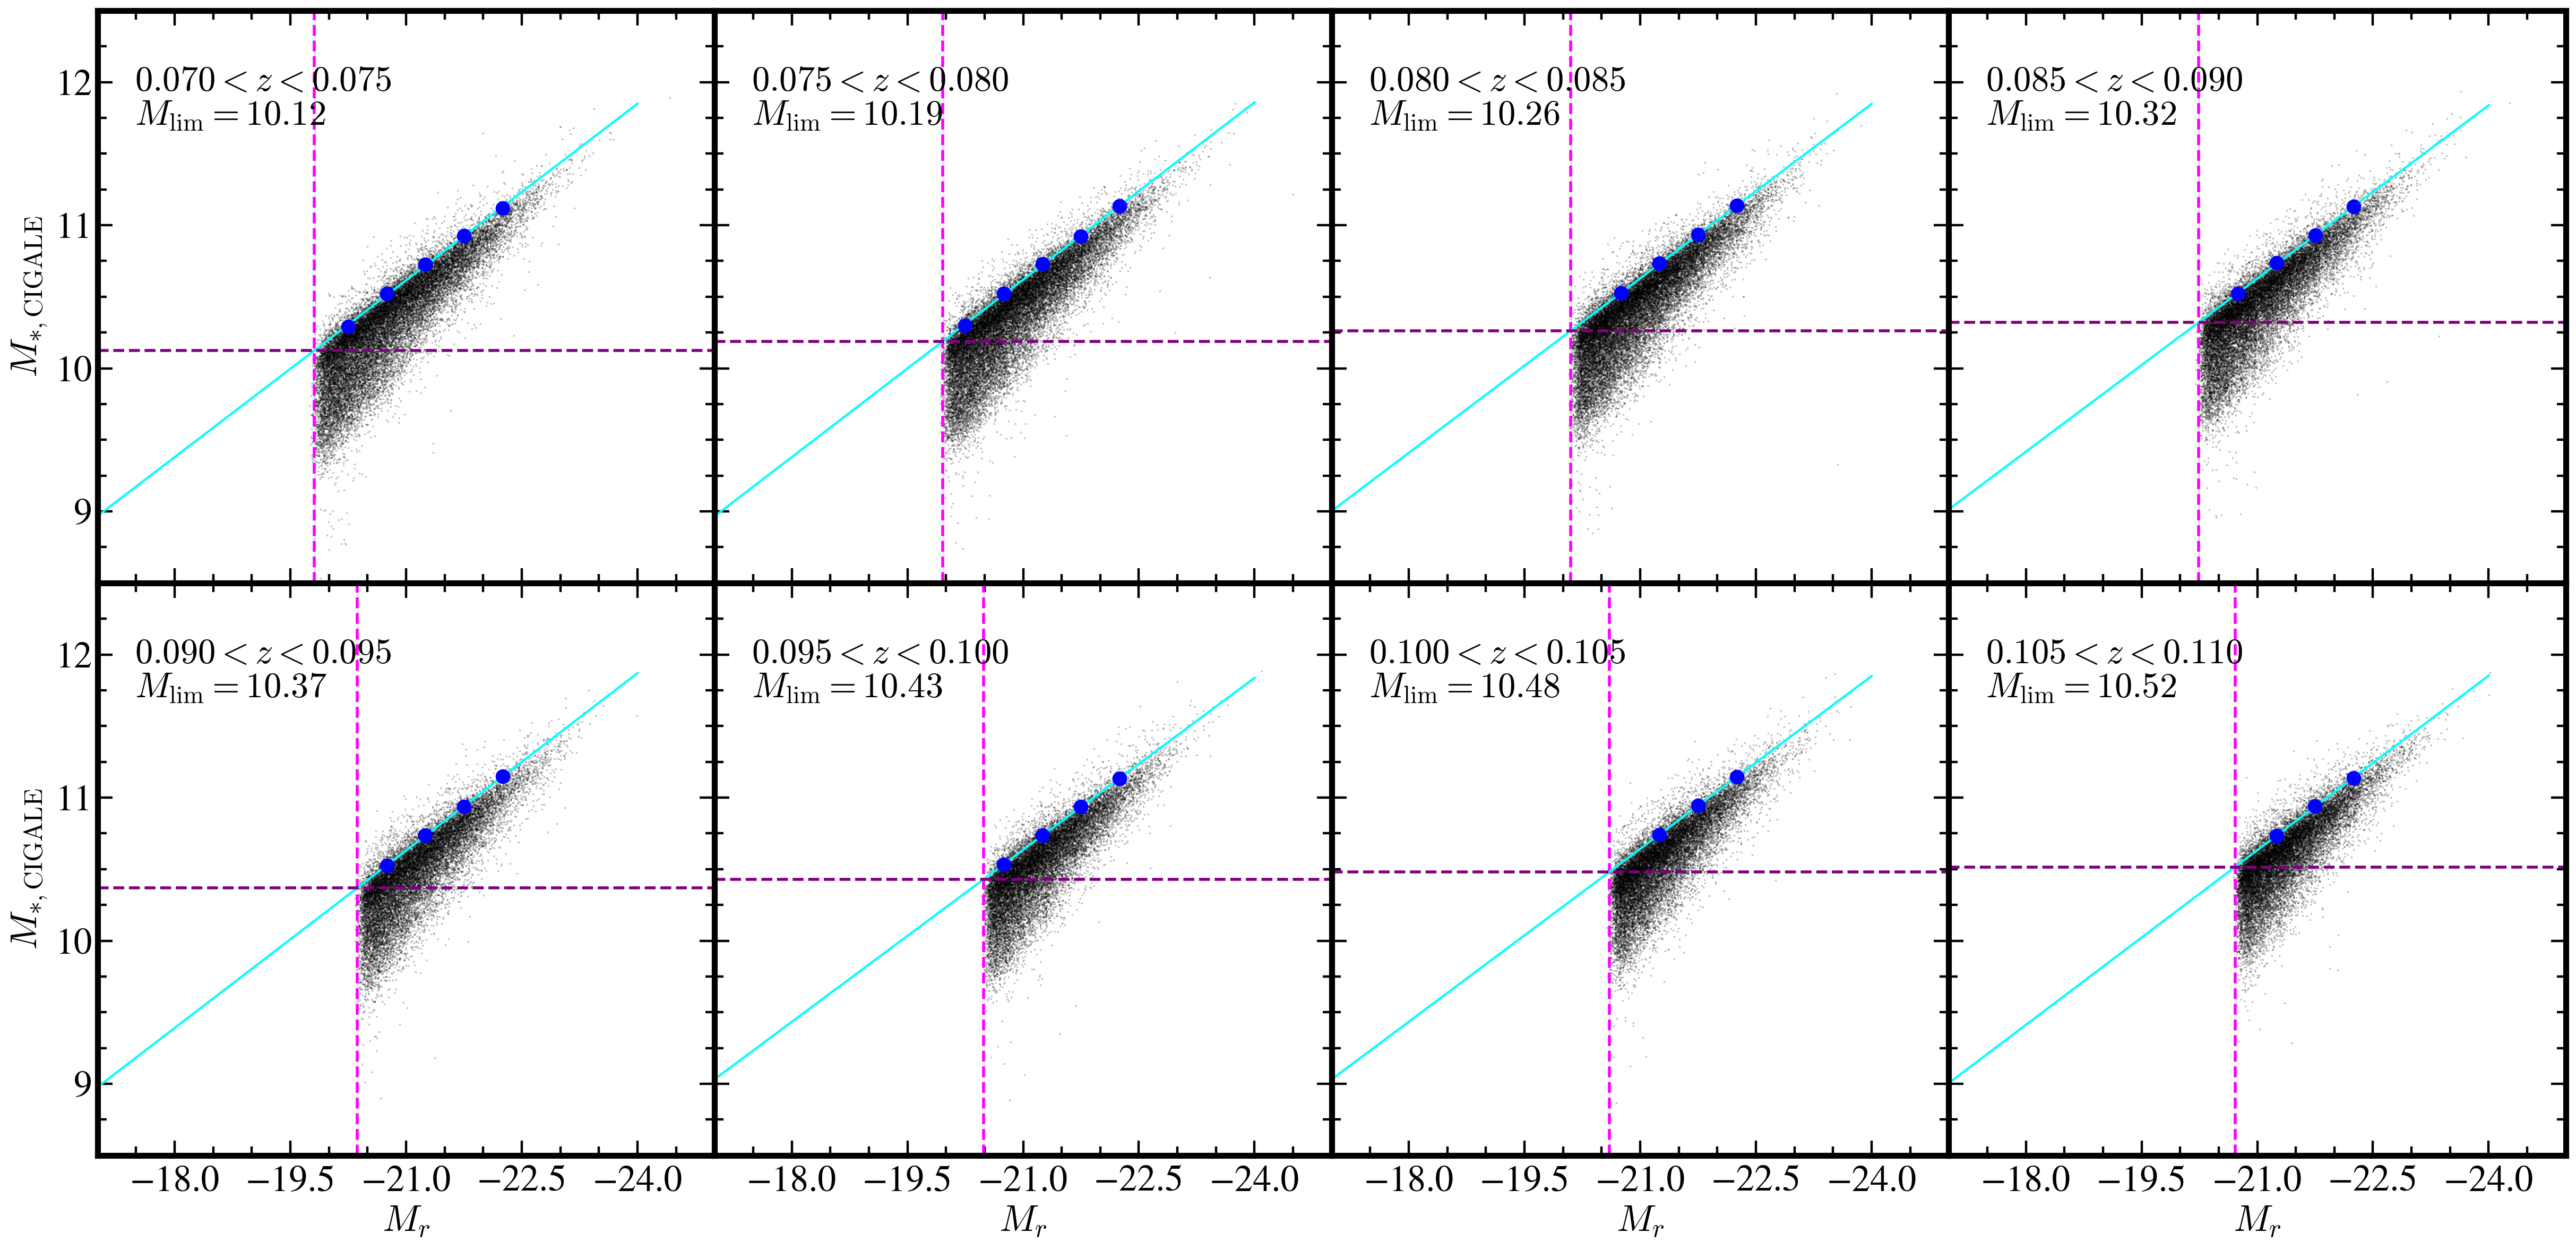

   z_center  M_star_lim
0    0.0725   10.122800
1    0.0775   10.188511
2    0.0825   10.263260
3    0.0875   10.319559
4    0.0925   10.367594
5    0.0975   10.429031
6    0.1025   10.481526
7    0.1075   10.515698


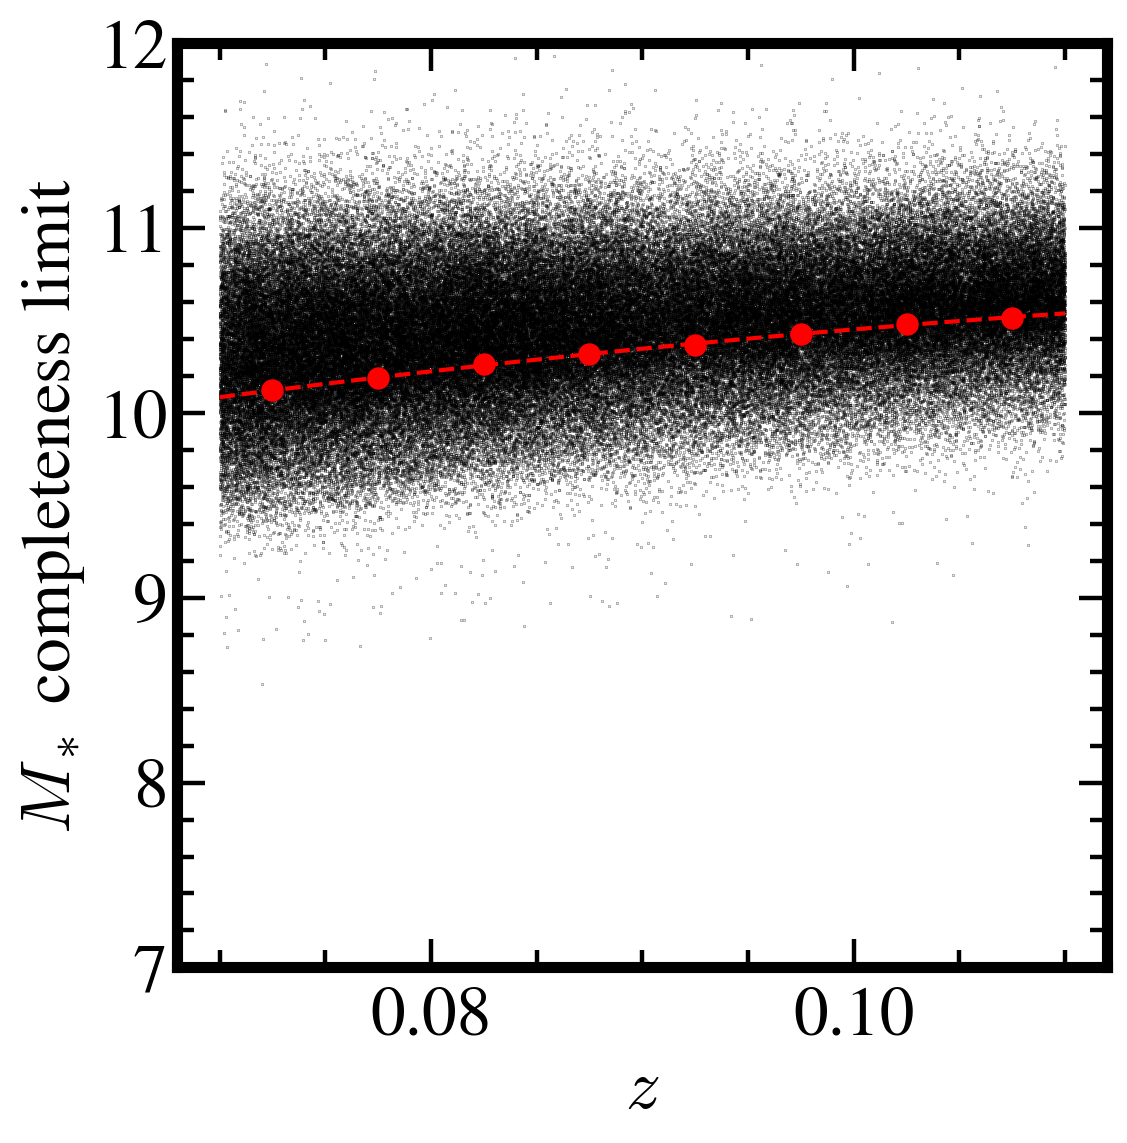

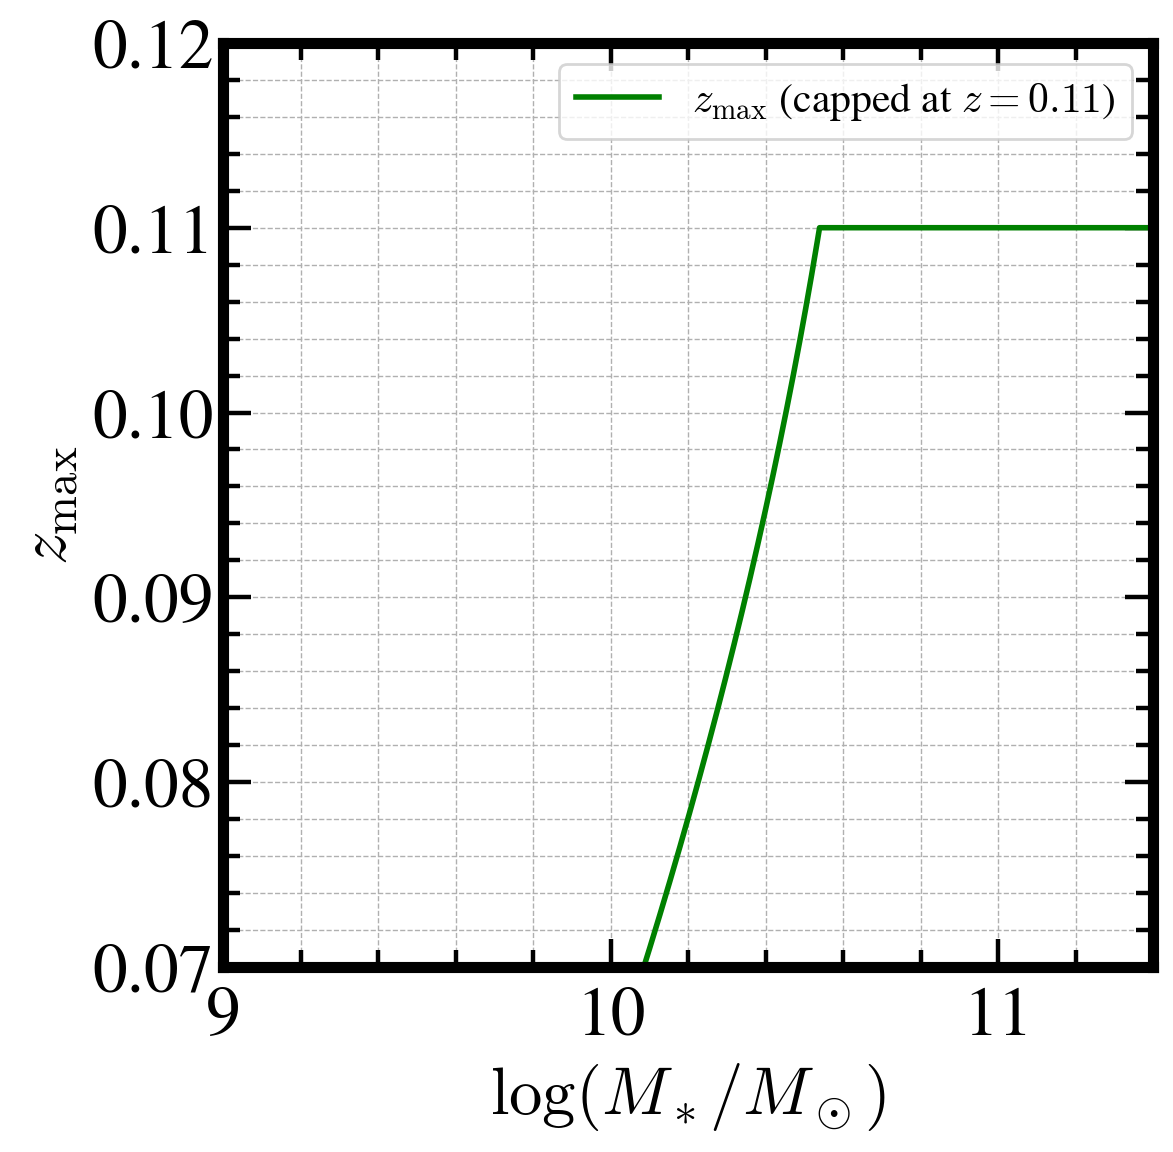

  0%|          | 0/5000 [00:00<?, ?it/s]/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 5000/5000 [00:02<00:00, 1941.89it/s]


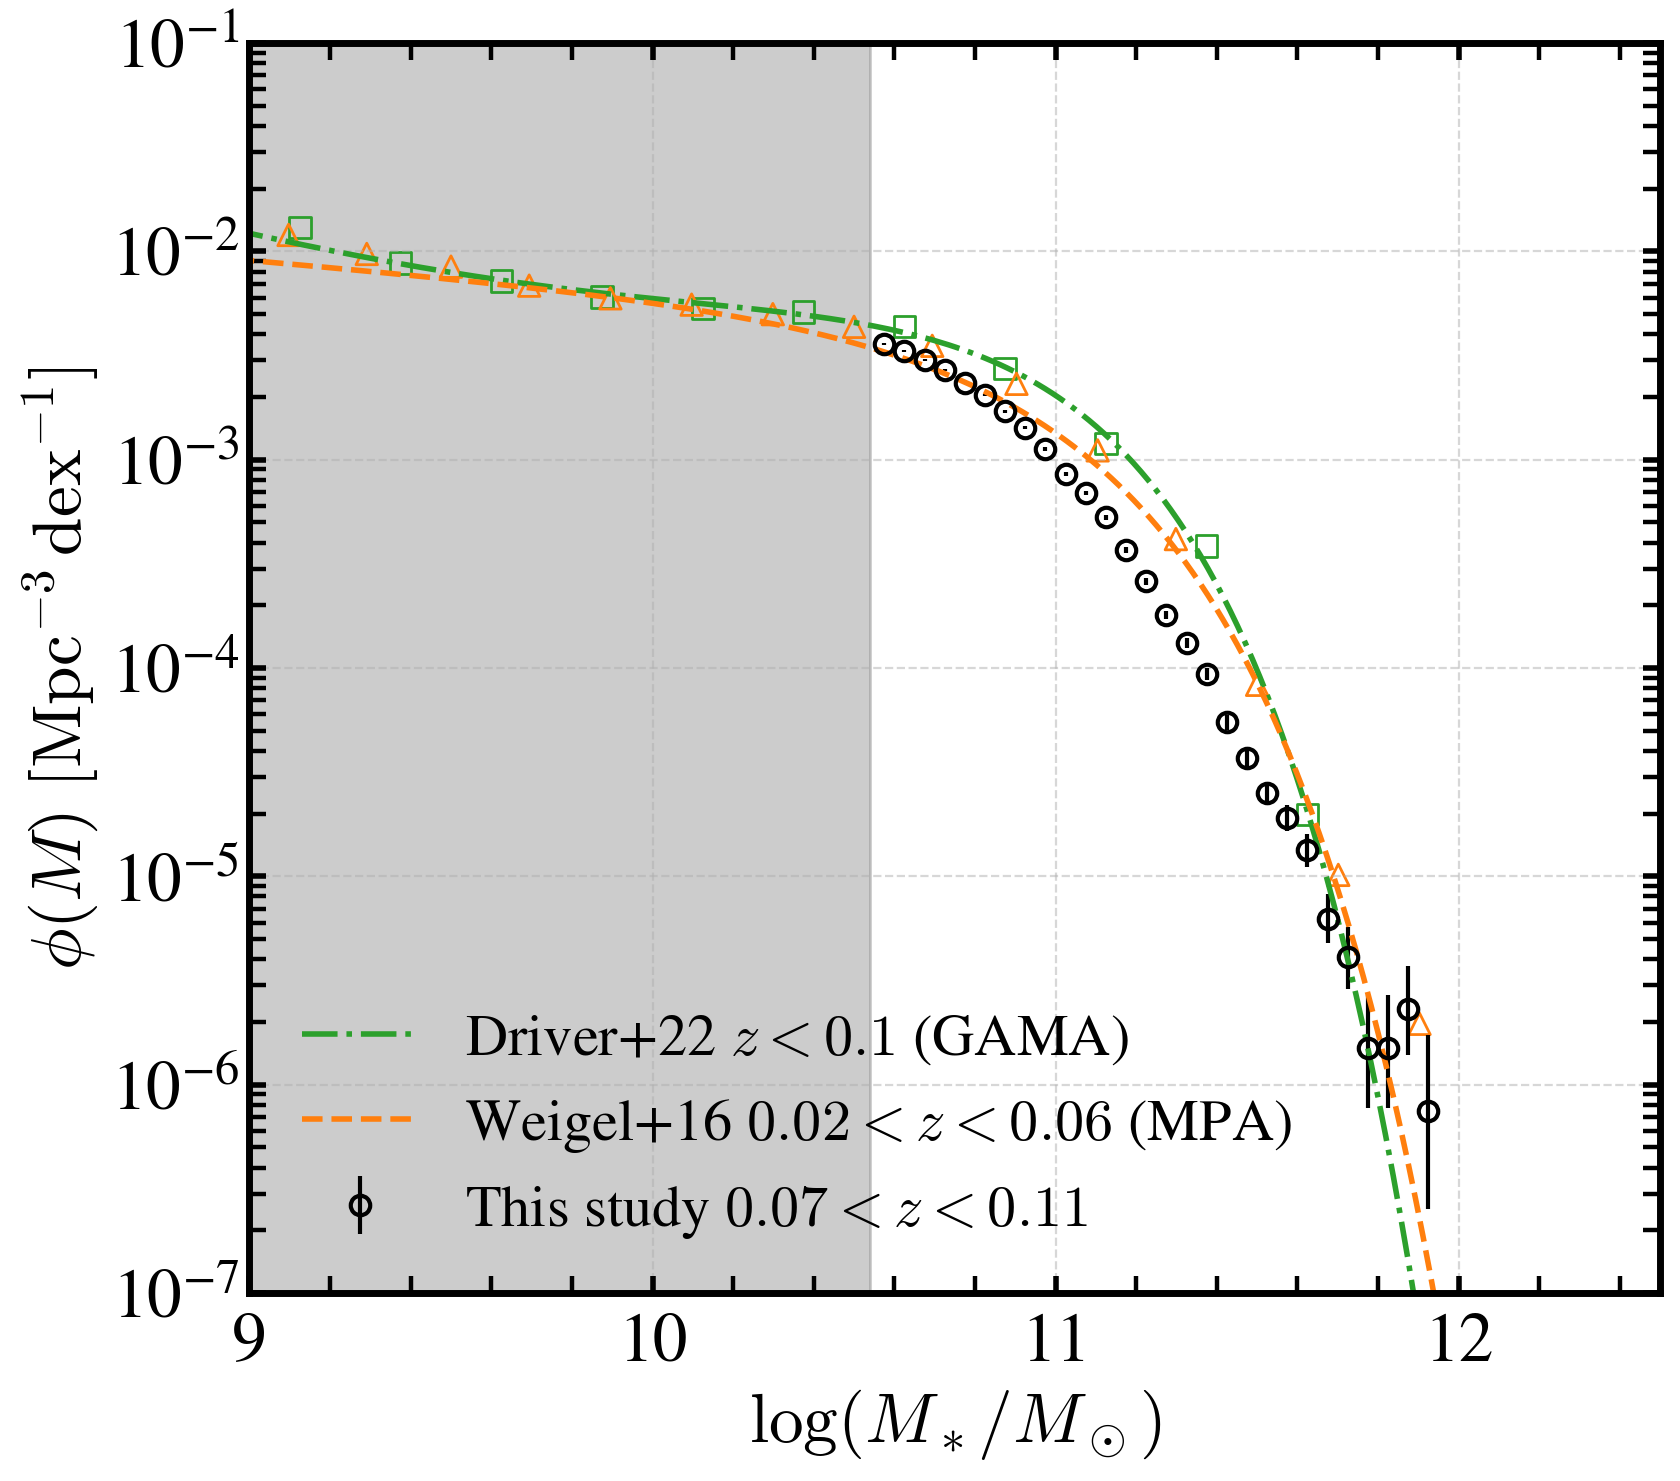

In [4]:
# ============================================================
# Field Stellar Mass Function (SMF) via 1/V_max
# ============================================================
# Overview:
#   1.  For each redshift slice, find the stellar-mass completeness
#       limit by fitting a line to the upper envelope of the
#       M_* vs M_r scatter, then record where it intersects the
#       apparent-magnitude limit.
#   2.  Fit a 2nd-order polynomial to those completeness limits
#       as a function of redshift → completeness curve p(z).
#   3.  Invert p(z) to get z_max(M_*) for each galaxy.
#   4.  Compute V_max for each galaxy and build the 1/V_max SMF
#       with Gehrels (1986) asymmetric Poisson errors.
#   5.  Fit double-Schechter models to literature SMFs (Driver+22,
#       Weigel+16) with MCMC and overplot everything.
# ============================================================

from numpy.polynomial.polynomial import Polynomial
from sklearn.linear_model import LinearRegression
import emcee

# ──────────────────────────────────────────────────────────────
# SECTION 1: Apparent-magnitude completeness per redshift slice
# ──────────────────────────────────────────────────────────────
# Strategy: in each Δz = 0.005 slice, the faintest detectable
# galaxy sets an absolute-magnitude limit M_lim(z).  Galaxies
# just above that limit define the stellar-mass completeness
# boundary.  We find it by fitting a line to the 90th-percentile
# M_* envelope in bins of M_r and reading off M_* at M_lim.

z_bins      = np.arange(0.07, 0.11 + 0.005 / 2, 0.005)
z_bin_pairs = [(z_bins[i], z_bins[i + 1]) for i in range(len(z_bins) - 1)]

M_APP_LIMIT = 17.77   # SDSS MGS r-band apparent magnitude limit

completeness_records = []   # will hold (z_center, M_*_completeness_limit)

fig, axes = plt.subplots(2, 4, figsize=(30, 14), sharex=True, sharey=True)
axes_flat  = axes.flatten()

for i, (z_lo, z_hi) in enumerate(z_bin_pairs):
    ax = axes_flat[i]
    z_cen = 0.5 * (z_lo + z_hi)

    # Redshift slice
    in_slice = (df["z"] >= z_lo) & (df["z"] < z_hi)
    sub = df[in_slice]

    # Absolute-magnitude limit at the bin centre
    d_l   = cosmo.luminosity_distance(z_cen).value          # Mpc
    M_lim = M_APP_LIMIT - 5.0 * (np.log10(d_l * 1e6) - 1)

    # Keep only galaxies brighter than the limit and not BCG-bright
    sub_filt = sub[(sub["AbsMag_r"] < M_lim) & (sub["AbsMag_r"] > -22.5)]

    # 90th-percentile M_* in 0.5-mag bins of M_r
    mag_bins = np.arange(sub_filt["AbsMag_r"].min(), sub_filt["AbsMag_r"].max(), 0.5)
    grouped  = sub_filt.groupby(pd.cut(sub_filt["AbsMag_r"], mag_bins, include_lowest=True))

    bin_mids, p90_mass = [], []
    for interval, grp in grouped:
        if not grp.empty:
            bin_mids.append(interval.mid)
            p90_mass.append(grp["M_MASS_CIGALE"].quantile(0.90))

    bin_mids  = np.array(bin_mids)
    p90_mass  = np.array(p90_mass)

    # Linear fit to the 90th-percentile ridge
    reg   = LinearRegression().fit(bin_mids.reshape(-1, 1), p90_mass)
    x_fit = np.linspace(-24, -15, 100)
    y_fit = reg.predict(x_fit.reshape(-1, 1))

    # Stellar-mass completeness limit = fit value at M_lim
    M_star_lim = reg.predict([[M_lim]])[0]
    completeness_records.append({"z_center": z_cen, "M_star_lim": M_star_lim})

    # ── Panel plot ─────────────────────────────────────────
    ax.scatter(sub["AbsMag_r"], sub["M_MASS_CIGALE"], color="black", s=0.01)
    ax.axvline(M_lim, color="magenta",  linestyle="--", label=r"$M_{\rm lim}$")
    ax.scatter(bin_mids, p90_mass, color="blue", s=80, zorder=5)
    ax.plot(x_fit, y_fit, color="cyan",   lw=1.5)
    ax.axhline(M_star_lim, color="purple", linestyle="--")

    ax.tick_params(axis="x", which="both", direction="in",
                   top=True, labelbottom=(i // 4 == 1))
    ax.tick_params(axis="y", which="both", direction="in",
                   right=True, labelleft=(i % 4 == 0))
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax.xaxis.set_major_locator(plt.MultipleLocator(1.5))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.25))

    if i % 4 == 0:
        ax.set_ylabel(r"$M_{\ast,\rm CIGALE}$")
    if i // 4 == 1:
        ax.set_xlabel(r"$M_r$")

    ax.set_xlim(-25, -17)
    ax.invert_xaxis()
    ax.set_ylim(8.5, 12.5)

    ax.text(0.06, 0.86, f"${z_lo:.3f}<z<{z_hi:.3f}$",
            transform=ax.transAxes, fontsize=24)
    ax.text(0.06, 0.80, rf"$M_{{\rm lim}}={M_star_lim:.2f}$",
            transform=ax.transAxes, fontsize=24)

# Hide unused panels if fewer than 8 bins
for ax in axes_flat[len(z_bin_pairs):]:
    ax.axis("off")

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

df_compline = pd.DataFrame(completeness_records)
print(df_compline)

# ──────────────────────────────────────────────────────────────
# SECTION 2: Fit 2nd-order polynomial to completeness limits
# ──────────────────────────────────────────────────────────────
# p(z) maps redshift → stellar-mass completeness limit.
# The inverse p^{-1}(M_*) gives the maximum redshift at which
# a galaxy of mass M_* would still be detected.

p = Polynomial.fit(df_compline["z_center"], df_compline["M_star_lim"], deg=2)
z_arr = np.linspace(0.07, 0.11, 100)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["z"],                  df["M_MASS_CIGALE"],       s=0.01, color="black")
ax.scatter(df_compline["z_center"],  df_compline["M_star_lim"], s=50,   color="red")
ax.plot(z_arr, p(z_arr), "r--", lw=1.5, label="2nd-order polynomial")
ax.set_xlabel("$z$")
ax.set_ylabel("$M_*$ completeness limit")
ax.set_ylim(7, 12)
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax.minorticks_on()
plt.show()

# Keep only galaxies above the completeness boundary
df_complete = df[df["M_MASS_CIGALE"] > p(df["z"])].copy()

# ──────────────────────────────────────────────────────────────
# SECTION 3: z_max per galaxy (inverse of completeness polynomial)
# ──────────────────────────────────────────────────────────────
# Solve p(z) = M_* for z:  a2·z² + a1·z + a0 = M_*
# → take the physically meaningful root, then cap at z_sample_max.

coeffs = p.convert().coef          # [a0, a1, a2] in standard (non-Chebyshev) basis
a0, a1, a2 = coeffs[0], coeffs[1], coeffs[2]

Z_MIN        = 0.07
Z_SAMPLE_MAX = 0.11

def inverse_completeness_poly(logM: np.ndarray) -> np.ndarray:
    """
    Return the redshift at which the completeness limit equals logM,
    i.e., solve a2·z² + a1·z + (a0 − logM) = 0.
    The discriminant is clipped to 0 to avoid NaN near the vertex.
    """
    disc    = np.clip(a1**2 - 4.0 * a2 * (a0 - logM), 0.0, None)
    z_plus  = (-a1 + np.sqrt(disc)) / (2.0 * a2)
    z_minus = (-a1 - np.sqrt(disc)) / (2.0 * a2)
    return np.where(z_plus >= 0, z_plus, z_minus)

def zmax_per_galaxy(logM: np.ndarray, z_max_survey: float = Z_SAMPLE_MAX) -> np.ndarray:
    """
    Return the maximum observable redshift for each galaxy, capped
    at the survey boundary z_max_survey.
    """
    logM = np.atleast_1d(logM)
    return np.minimum(inverse_completeness_poly(logM), z_max_survey)

# Diagnostic plot: M_* → z_max curve
M_diag = np.linspace(7, 12, 10_000)
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(M_diag, zmax_per_galaxy(M_diag), color="green",
        label=rf"$z_{{\rm max}}$ (capped at $z={Z_SAMPLE_MAX}$)")
ax.set_xlabel(r"$\log(M_*/M_\odot)$", fontsize=24)
ax.set_ylabel(r"$z_{\rm max}$",       fontsize=24)
ax.set_xlim(9.0, 11.4)
ax.set_ylim(0.07, 0.12)
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax.minorticks_on()
ax.grid(which="both", linestyle="--", linewidth=0.5)
ax.legend(fontsize=15)
plt.show()

# ──────────────────────────────────────────────────────────────
# SECTION 4: V_max and 1/V_max SMF with Gehrels errors
# ──────────────────────────────────────────────────────────────

SURVEY_AREA_DEG2 = 8032.0
OMEGA_SR         = (SURVEY_AREA_DEG2 / 41_253.0) * 4.0 * np.pi   # survey solid angle [sr]

def comoving_volume(z_lo: float, z_hi: float) -> float:
    """
    Comoving survey volume between z_lo and z_hi [Mpc³],
    scaled to the survey solid angle.
    """
    d_lo = cosmo.comoving_distance(z_lo).value   # Mpc
    d_hi = cosmo.comoving_distance(z_hi).value
    v_sphere = (4.0 / 3.0) * np.pi * (d_hi**3 - d_lo**3)
    return v_sphere * OMEGA_SR / (4.0 * np.pi)

# Assign z_max and V_max to each galaxy in the complete sample
df_complete["z_max"] = zmax_per_galaxy(df_complete["M_MASS_CIGALE"].values, Z_SAMPLE_MAX)
df_complete["V_max"] = df_complete["z_max"].apply(
    lambda z: comoving_volume(Z_MIN, z)
)

# Stellar-mass completeness limit at the survey redshift boundary
M_COMPLETE_LIM = p(Z_SAMPLE_MAX)   # log(M_*/M_sun)

# 1/V_max SMF in bins of Δlog(M_*) = 0.05 dex
BIN_WIDTH  = 0.05
mass_edges = np.arange(7.0, 13.0, BIN_WIDTH)
mass_cens  = mass_edges[:-1] + BIN_WIDTH / 2.0

phi_vals, err_up, err_lo = [], [], []

for m_lo, m_hi in zip(mass_edges[:-1], mass_edges[1:]):
    in_bin = (
        (df_complete["M_MASS_CIGALE"] >= m_lo) &
        (df_complete["M_MASS_CIGALE"] <  m_hi) &
        (df_complete["M_MASS_CIGALE"] >= M_COMPLETE_LIM)
    )
    gals = df_complete.loc[in_bin].copy()

    if len(gals) == 0:
        phi_vals.append(np.nan)
        err_up.append(np.nan)
        err_lo.append(np.nan)
        continue

    w     = gals["w_spec"] / gals["V_max"]      # 1/V_max weights
    phi_j = w.sum() / BIN_WIDTH                  # SMF value [Mpc⁻³ dex⁻¹]

    # Effective galaxy count for Poisson statistics (Gehrels 1986)
    w_eff = (w**2).sum() / w.sum()               # effective weight per galaxy
    n_eff = w.sum() / w_eff

    # Gehrels (1986) 1σ asymmetric Poisson upper and lower limits
    n_up  = n_eff + np.sqrt(n_eff + 0.75) + 1.0
    n_lo  = n_eff - np.sqrt(n_eff - 0.25)

    phi_vals.append(phi_j)
    err_up.append(-phi_j + w_eff * n_up / BIN_WIDTH)
    err_lo.append( phi_j - w_eff * n_lo / BIN_WIDTH)

phi_arr    = np.array(phi_vals)
err_up_arr = np.array(err_up)
err_lo_arr = np.array(err_lo)

# Convert to log space for plotting
log_phi      = np.log10(phi_arr)
log_err_up   = np.log10(phi_arr + err_up_arr) - log_phi
log_err_lo   = log_phi - np.log10(phi_arr - err_lo_arr)

# ──────────────────────────────────────────────────────────────
# SECTION 5: MCMC double-Schechter fits to literature SMFs
# ──────────────────────────────────────────────────────────────

def double_schechter(logM: np.ndarray,
                     phi1: float, phi2: float, logM_star: float,
                     alpha1: float, alpha2: float) -> np.ndarray:
    """
    Double Schechter function in log-mass form.
    Equation: Φ(M) = ln(10)·e^{-10^{M−M*}} ·
                     [Φ1·10^{(1+α1)(M−M*)} + Φ2·10^{(1+α2)(M−M*)}]
    """
    ln10 = np.log(10)
    x    = 10.0 ** (logM - logM_star)
    return ln10 * np.exp(-x) * (phi1 * x**(1.0 + alpha1) + phi2 * x**(1.0 + alpha2))

def log_prior_ds(theta: tuple) -> float:
    phi1, phi2, logM_star, alpha1, alpha2 = theta
    if (0 < phi1 < 1) and (0 < phi2 < 1) and \
       (8 < logM_star < 13) and (-5 < alpha1 < 2) and (-5 < alpha2 < 2):
        return 0.0
    return -np.inf

def log_likelihood_ds(theta: tuple, logM: np.ndarray, phi: np.ndarray) -> float:
    model = double_schechter(logM, *theta)
    sigma = 0.1 * phi                            # 10 % fractional uncertainty
    return -0.5 * np.sum(((phi - model) / sigma)**2 + np.log(2.0 * np.pi * sigma**2))

def log_posterior_ds(theta, logM, phi):
    lp = log_prior_ds(theta)
    return lp + log_likelihood_ds(theta, logM, phi) if np.isfinite(lp) else -np.inf

def fit_double_schechter_mcmc(
    logM: np.ndarray,
    phi:  np.ndarray,
    p0:   list,
    nwalkers: int = 32,
    nsteps:   int = 5000,
    n_burn:   int = 1000,
) -> np.ndarray:
    """
    Run emcee to fit a double-Schechter model.
    Returns the median posterior parameter vector.
    """
    ndim  = len(p0)
    pos   = np.array(p0) + 1e-4 * np.random.randn(nwalkers, ndim)
    sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior_ds, args=(logM, phi))
    sampler.run_mcmc(pos, nsteps, progress=True)
    return np.median(sampler.get_chain(discard=n_burn, flat=True), axis=0)

# Load literature SMF tables
driver_df = pd.read_csv(f"{MAINPATH}/DATA/LITERATURE_TABLES/Driver2022_Tab6_FieldSMF_data.csv")
weigel_df = pd.read_csv(f"{MAINPATH}/DATA/LITERATURE_TABLES/Weigel2016_Fig6_FieldSMF_data.csv")

driver_df["Mass"] = driver_df["log10(M)"]
driver_df["phi"]  = 10.0 ** driver_df["All"]

# Weigel uses h = 1; rescale to our cosmology (h = cosmo.h)
weigel_df["Mass"] = weigel_df["log10(M)"]
weigel_df["phi"]  = 10.0 ** weigel_df["phi"] * cosmo.h**3

# Drop NaN rows before fitting
ok_drv = driver_df[["Mass", "phi"]].dropna()
ok_wgl = weigel_df[["Mass", "phi"]].dropna()

# Initial guesses: [phi1, phi2, logM*, alpha1, alpha2]
p0_driver = [1e-3, 5e-5, 10.6, -0.2, -1.4]
p0_weigel = [1e-3, 1e-2, 10.8, -0.7, -1.7]

med_driver = fit_double_schechter_mcmc(ok_drv["Mass"].values, ok_drv["phi"].values, p0_driver)
med_weigel = fit_double_schechter_mcmc(ok_wgl["Mass"].values, ok_wgl["phi"].values, p0_weigel)

M_model    = np.linspace(7.0, 12.5, 300)
curve_drv  = double_schechter(M_model, *med_driver)
curve_wgl  = double_schechter(M_model, *med_weigel)

# ──────────────────────────────────────────────────────────────
# SECTION 6: Final SMF comparison plot
# ──────────────────────────────────────────────────────────────

# This-study data points (above completeness limit, valid bins only)
valid      = ~np.isnan(log_phi) & (mass_cens >= M_COMPLETE_LIM)
M_this     = mass_cens[valid]
phi_this   = 10.0 ** log_phi[valid]
yerr_lo    = phi_this - 10.0 ** (log_phi[valid] - log_err_lo[valid])
yerr_hi    = 10.0 ** (log_phi[valid] + log_err_up[valid]) - phi_this

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_yscale("log")
ax.set_xlim(9.0, 12.5)
ax.set_ylim(1e-7, 1e-1)

# Gray region: below completeness limit
ax.axvspan(7.0, M_COMPLETE_LIM, color="gray", alpha=0.4)

# This study
ax.errorbar(
    M_this, phi_this,
    yerr=[yerr_lo, yerr_hi],
    fmt="o", mfc="none", mec="black",
    ms=7, mew=1.5, ecolor="black", elinewidth=1.5,
    capsize=0, label=r"This study $0.07 < z < 0.11$",
)

# Driver+22 (GAMA)
ax.scatter(ok_drv["Mass"], ok_drv["phi"],
           marker="s", facecolors="none", edgecolors="C2", s=60)
ax.plot(M_model, curve_drv, ls="-.", color="C2", lw=2,
        label=r"Driver+22 $z<0.1$ (GAMA)")

# Weigel+16 (MPA)
ax.scatter(ok_wgl["Mass"], ok_wgl["phi"],
           marker="^", facecolors="none", edgecolors="C1", s=60)
ax.plot(M_model, curve_wgl, ls="--", color="C1", lw=2,
        label=r"Weigel+16 $0.02 < z < 0.06$ (MPA)")

ax.set_xlabel(r"$\log(M_*/M_\odot)$")
ax.set_ylabel(r"$\phi(M)\ [\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}]$")
ax.tick_params(direction="in", top=True, right=True, width=2, length=6)
ax.minorticks_on()
ax.grid(True, which="major", linestyle="--", alpha=0.5)
for spine in ax.spines.values():
    spine.set_linewidth(2.5)
ax.legend(fontsize=21, loc="lower left", frameon=False)

plt.tight_layout()
plt.show()

In [5]:
# Collect total-field SMF measurements (black points in the final plot)
smf_data = pd.DataFrame({
    "logM": M_this,                 # bin centers [log(M*/Msun)]
    "phi_Mpc-3_dex-1": phi_this,    # SMF value φ(M) in linear units
    "phi_err_low": yerr_lo,         # lower 1σ error in linear units
    "phi_err_up": yerr_hi           # upper 1σ error in linear units
})

# Save to CSV (no index) and report where it was written
output_csv = "FieldSMF_total.csv"
smf_data.to_csv(output_csv, index=False)
print(f"Saved total-field SMF (black points) to '{output_csv}'")

Saved total-field SMF (black points) to 'FieldSMF_total.csv'


# 3. Field SMF ('induced' MPA mass from SDSS)

This section shows the field SMF using mock MPA stellar masses. Since we cannot directly use MPA masses for all galaxies, we use the empirical relation between MPA and SDSS masses to estimate what the SMF would look like if all galaxies had MPA masses. This approach helps resolve the discrepancies observed between field SMFs derived from different mass estimates.

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_70627/311063215.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = sub_filt.groupby(pd.cut(sub_filt["AbsMag_r"], mag_bins, include_lowest=True))
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_70627/311063215.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = sub_filt.groupby(pd.cut(sub_filt["AbsMag_r"], mag_bins, include_lowest=True))
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_70627/311063215.py:90: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future versi

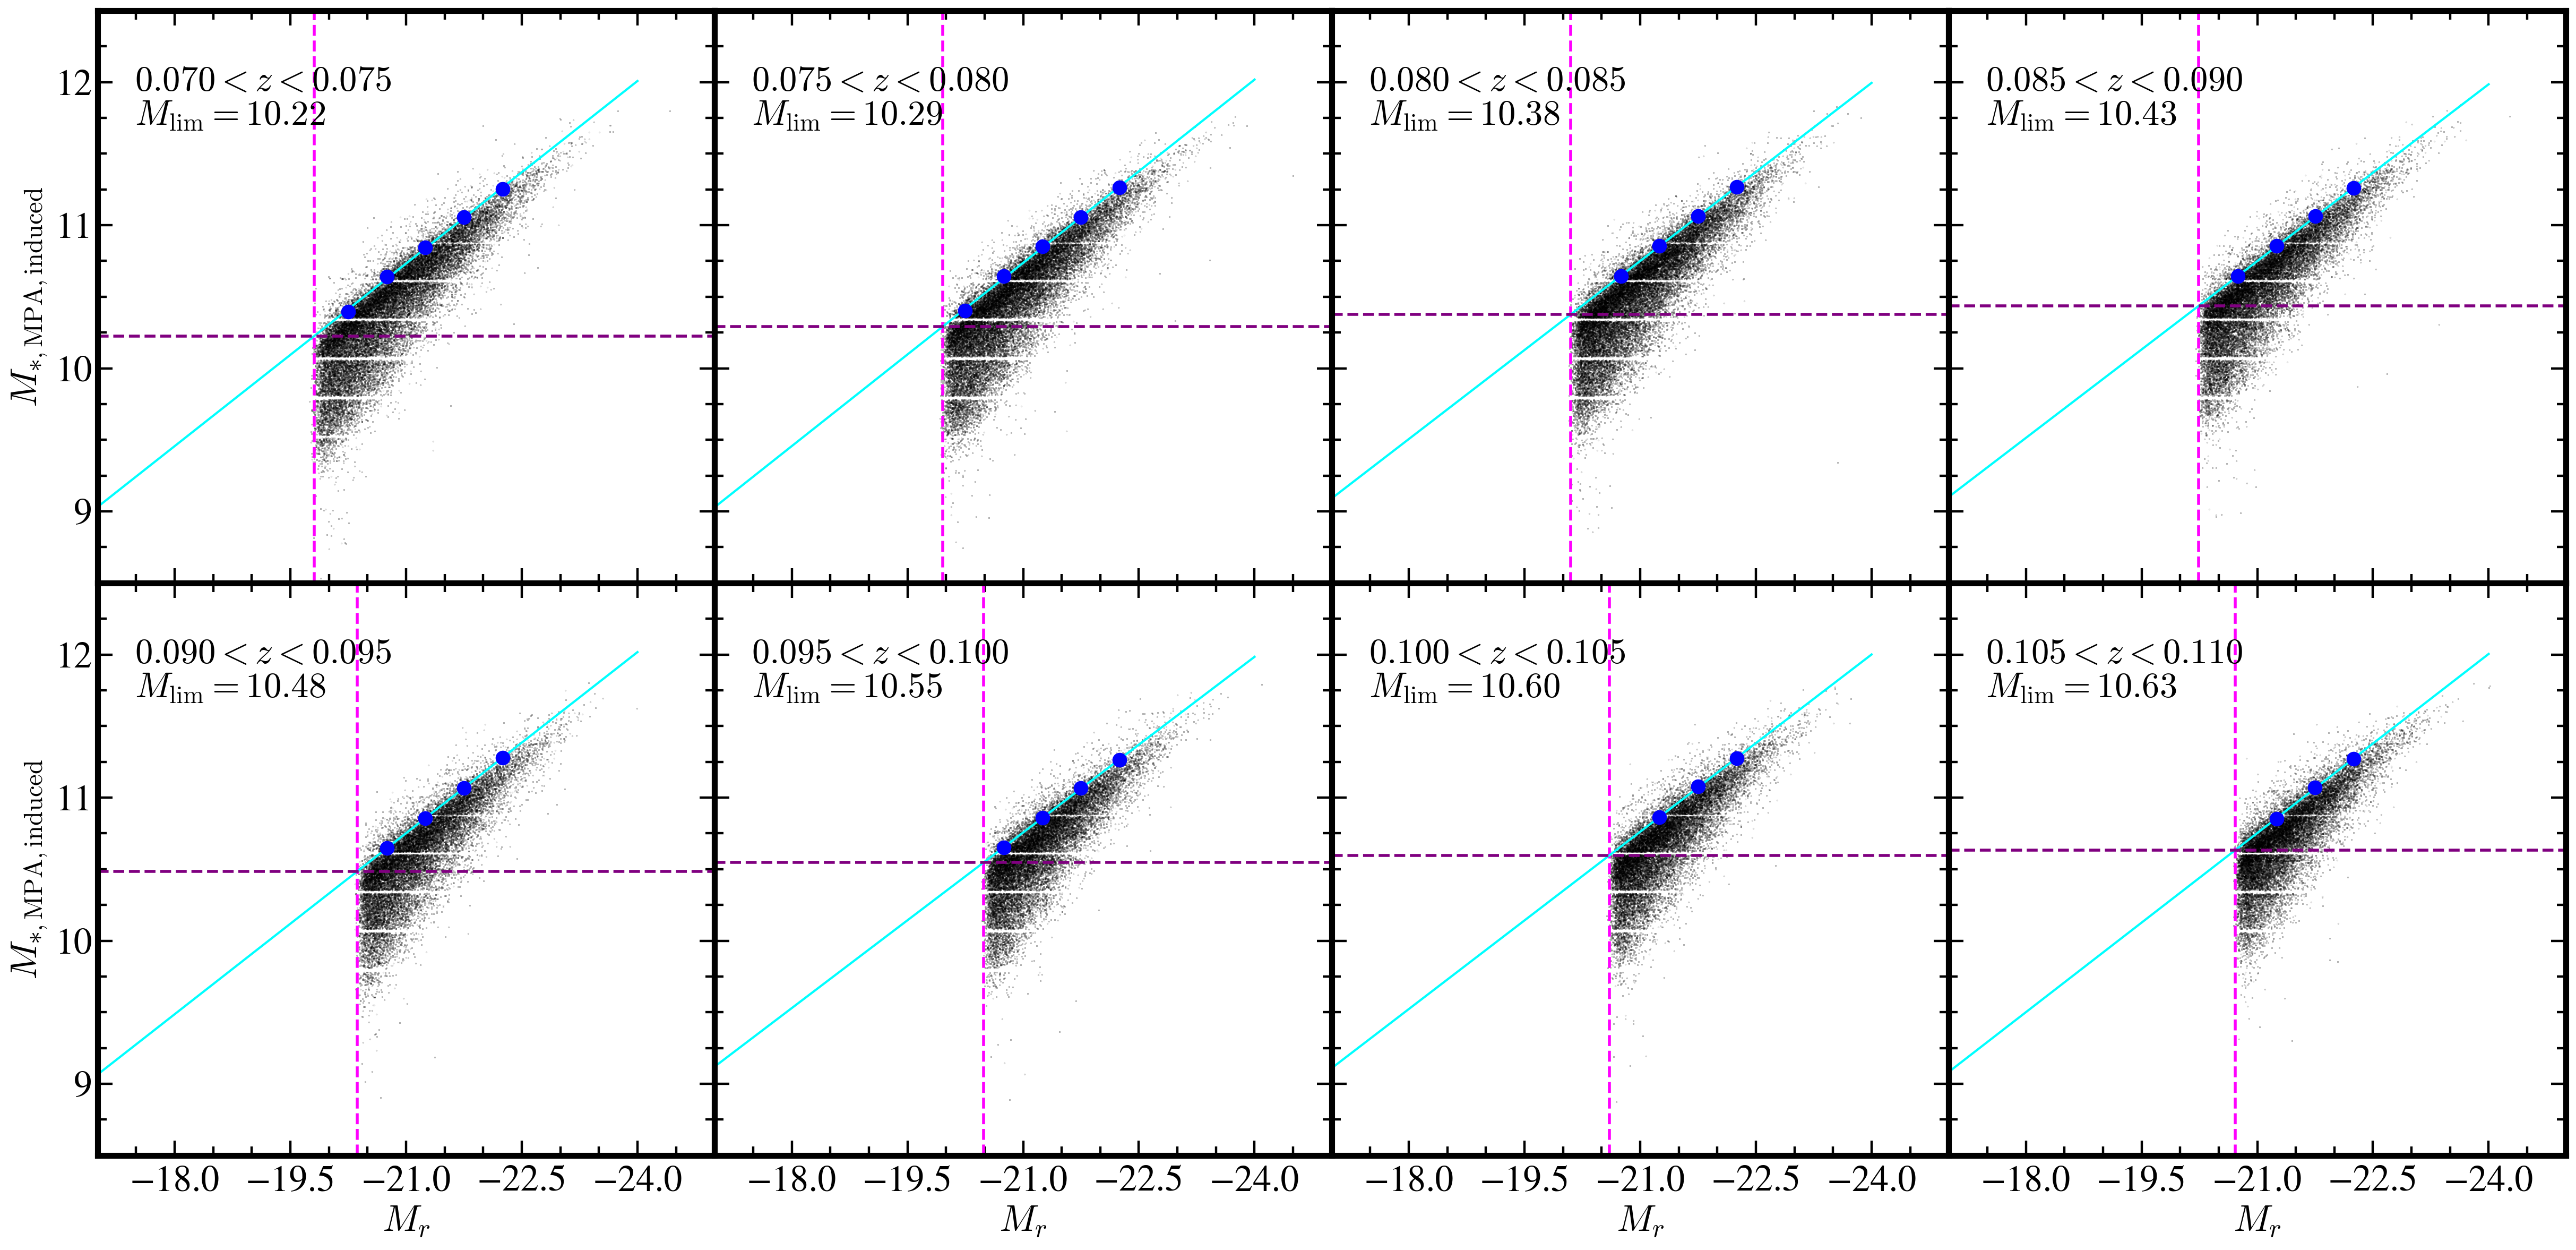

   z_center  M_star_lim
0    0.0725   10.224250
1    0.0775   10.292041
2    0.0825   10.377279
3    0.0875   10.434723
4    0.0925   10.483843
5    0.0975   10.546319
6    0.1025   10.597193
7    0.1075   10.632530


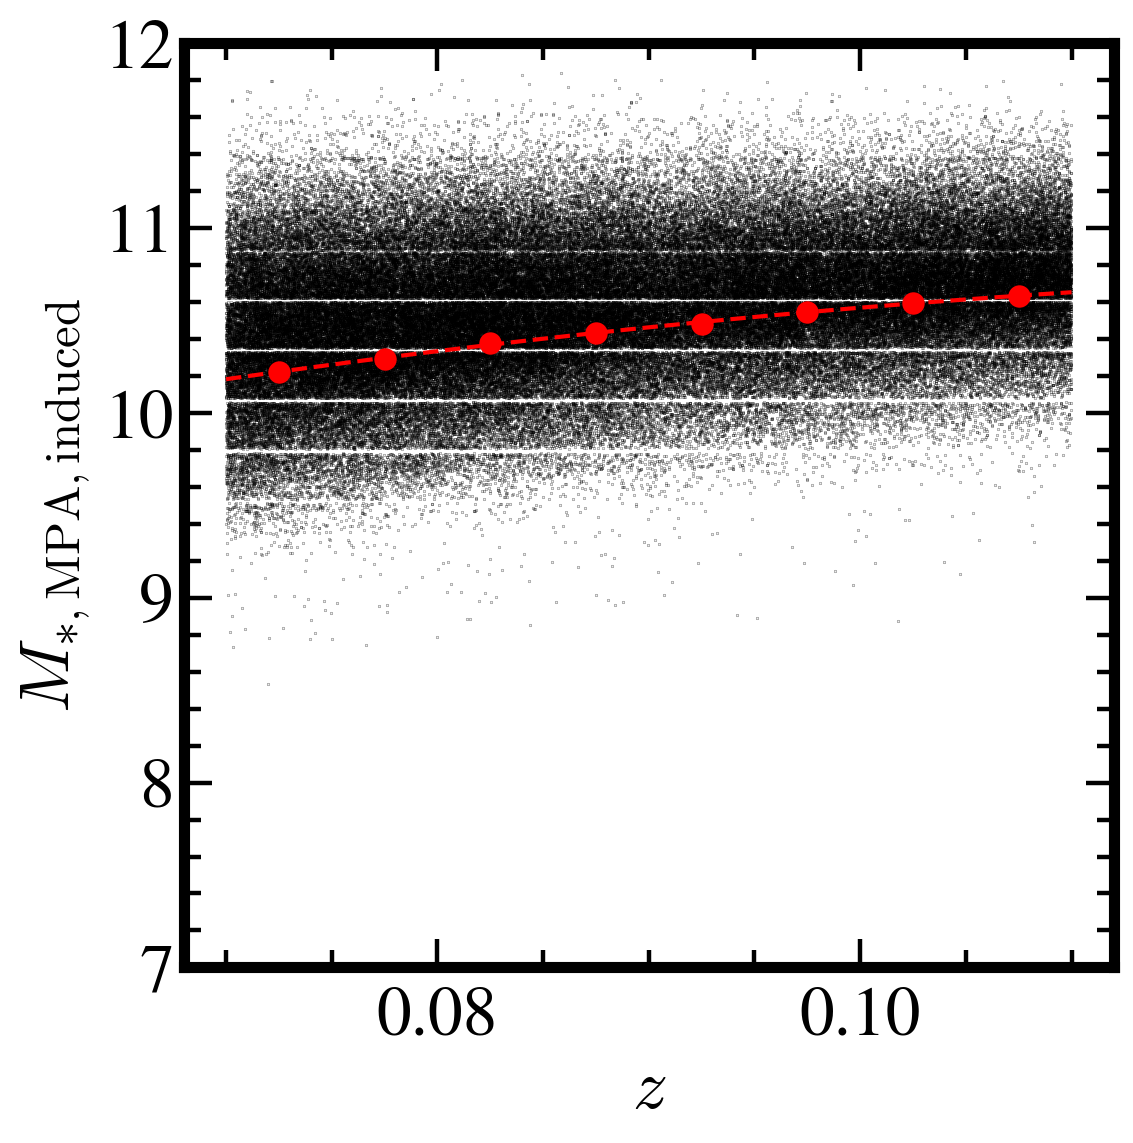

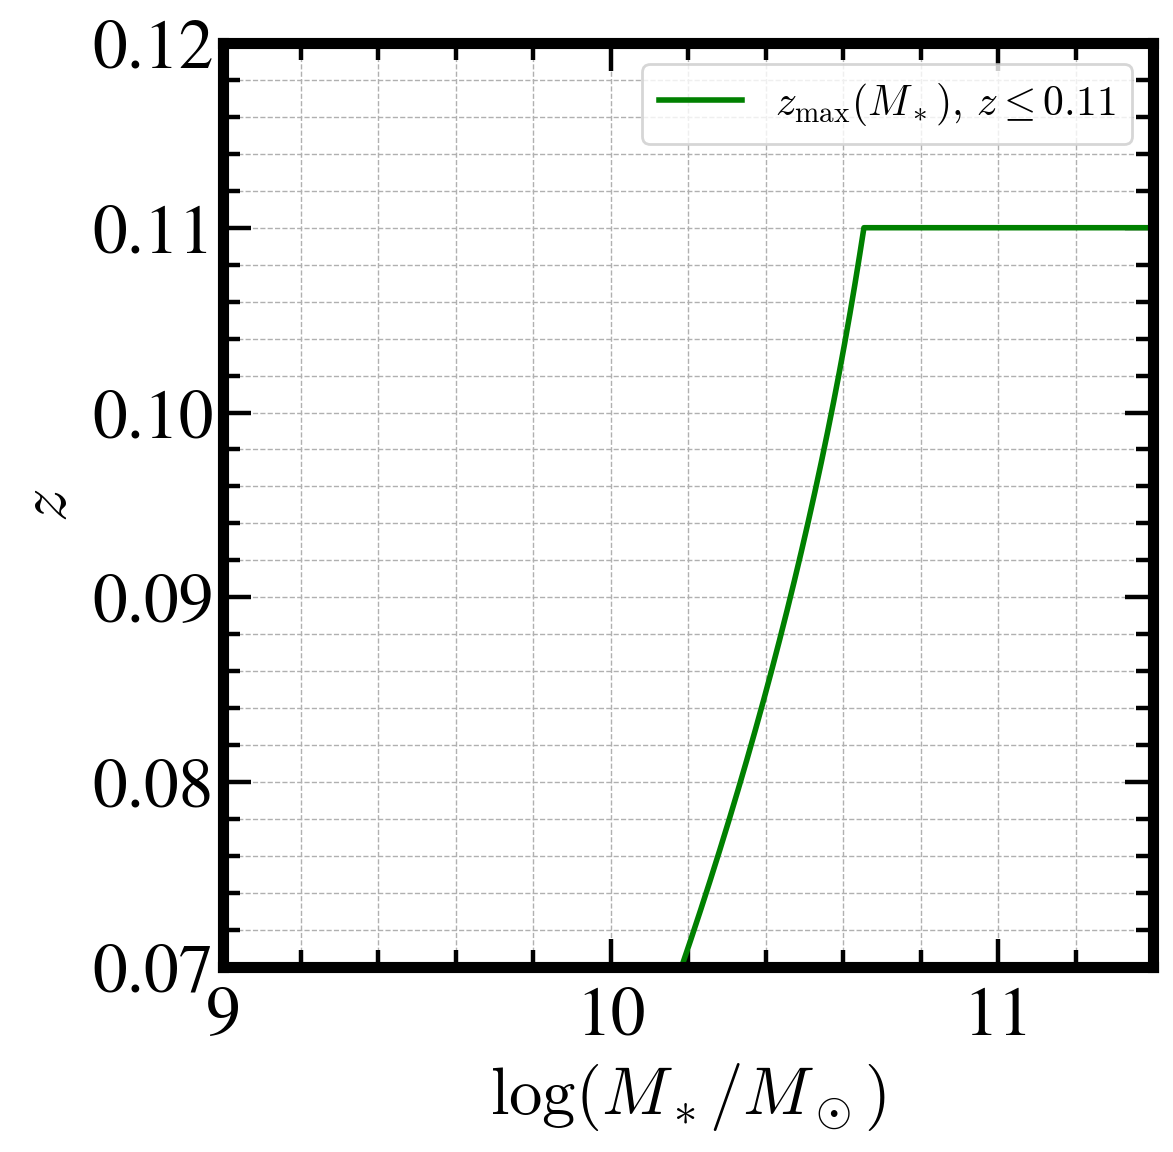

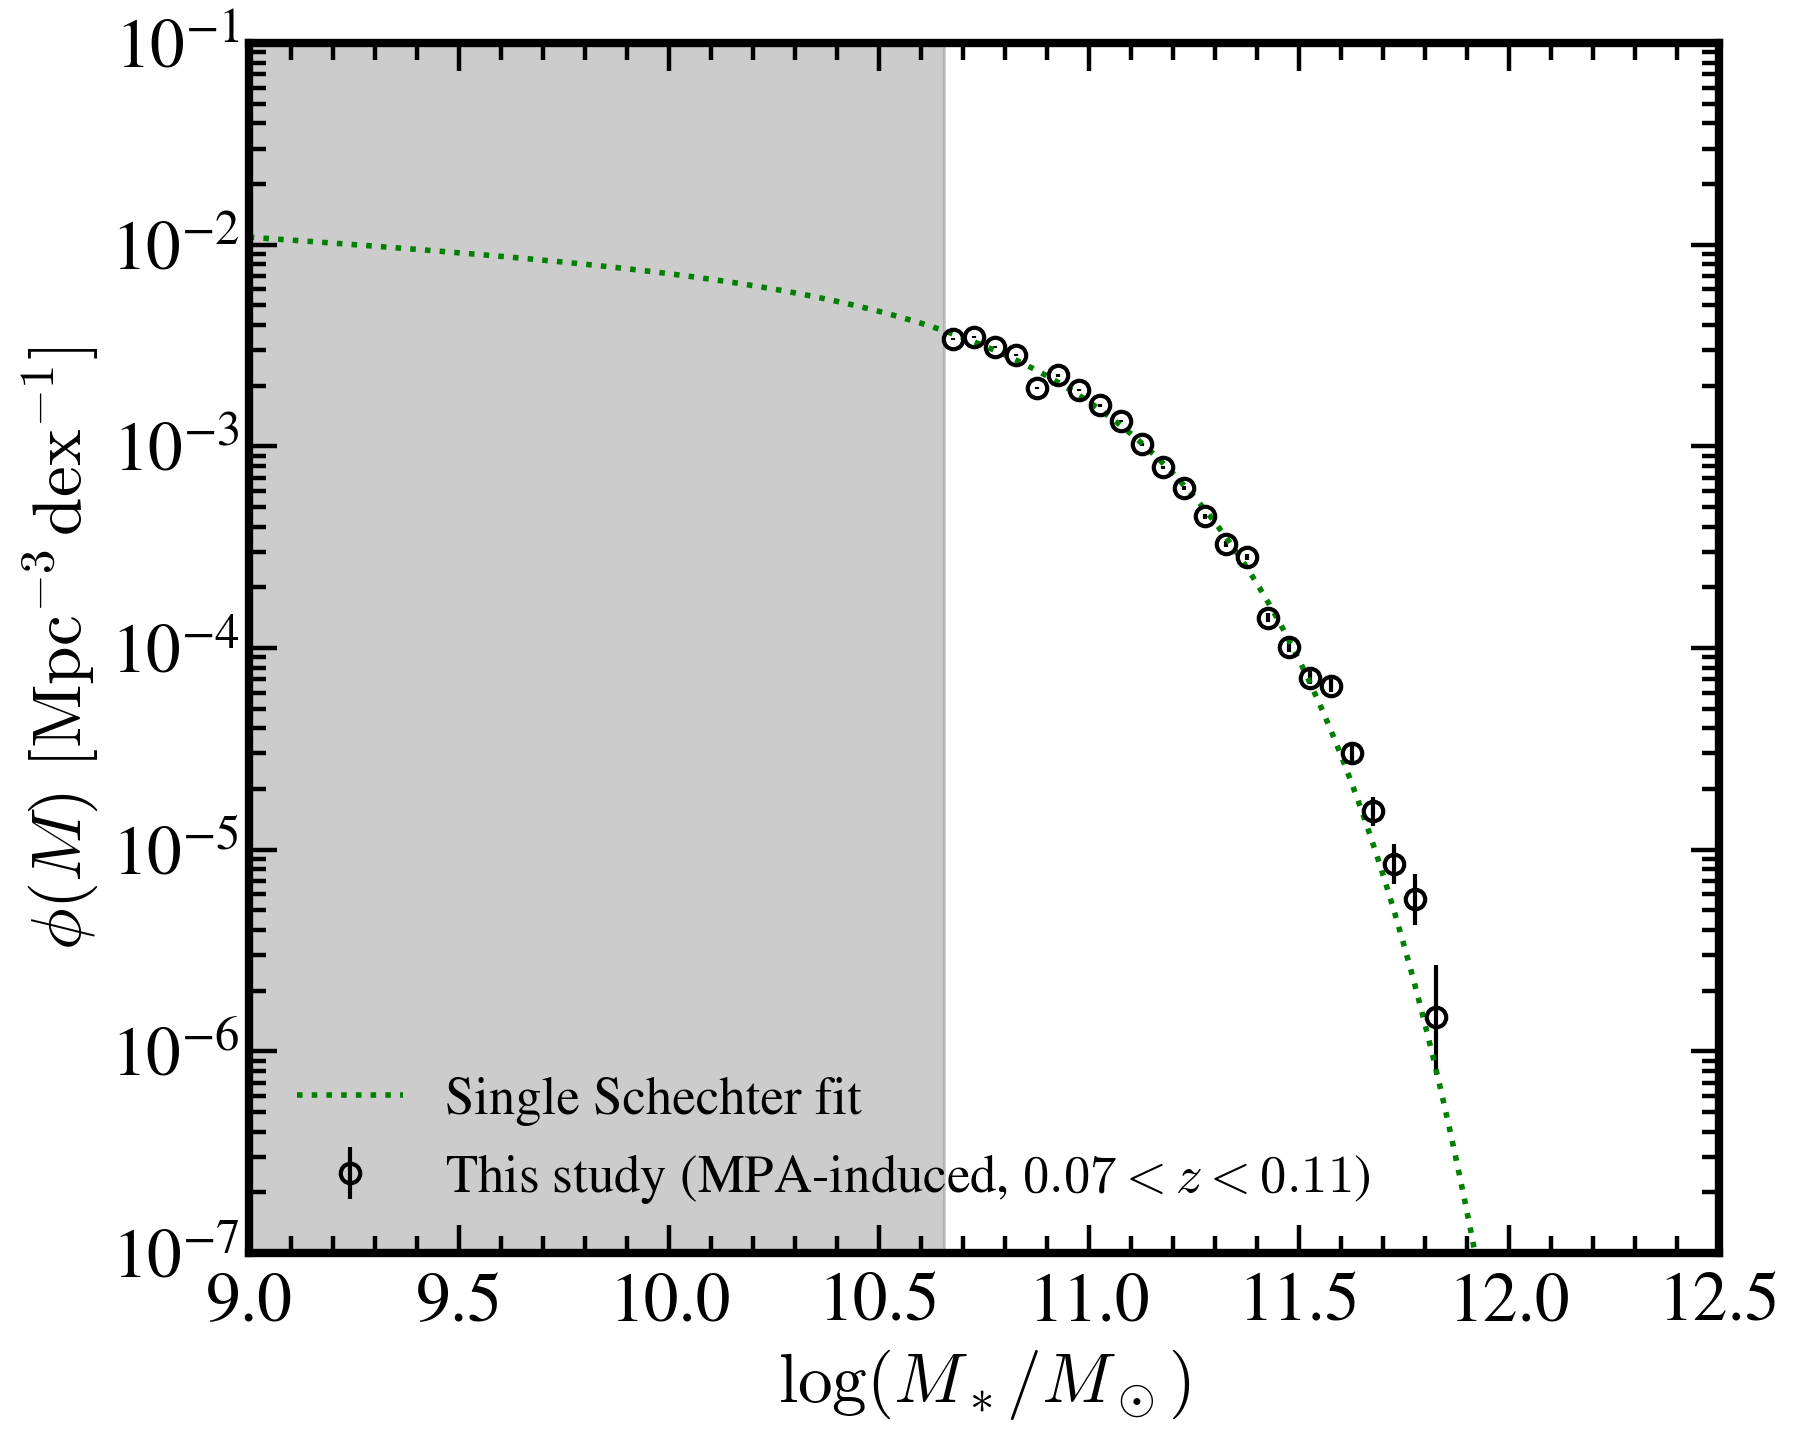

In [6]:
from numpy.polynomial.polynomial import Polynomial
from sklearn.linear_model import LinearRegression

# ============================================================
# 0. Apply stellar-mass offset: CIGALE → induced MPA masses
# ============================================================

# mass_offset_mpa_panel.csv must have columns:
#   - 'M_CIGALE'        : CIGALE mass bin center (log M*)
#   - 'median_Delta_M*' : median offset (MPA − CIGALE) in that bin
mass_offset = pd.read_csv(f"{MAINPATH}/DATA/FIELD/mass_offset_mpa_panel.csv")

# Rename for clarity
mass_offset = (
    mass_offset
    .rename(columns={"M_CIGALE": "bin_center", "median_Delta_M*": "median_delta"})
    .sort_values("bin_center")
)

# Sort main catalog by CIGALE mass for merge_asof
df_sorted = df.sort_values("M_MASS_CIGALE")

# Nearest-neighbor merge to attach an offset ΔM* to each galaxy
df_merged = pd.merge_asof(
    df_sorted,
    mass_offset[["bin_center", "median_delta"]],
    left_on="M_MASS_CIGALE",
    right_on="bin_center",
    direction="nearest",
)

# Induced MPA-like stellar mass
df_merged["M_MASS_MPA_induced"] = (
    df_merged["M_MASS_CIGALE"] + df_merged["median_delta"]
)

# Drop helper columns and restore original row order
df = (
    df_merged
    .drop(columns=["bin_center", "median_delta"])
    .sort_index()
)

# ============================================================
# 1. Completeness in (M_r, M_*_MPA_induced) per redshift slice
# ============================================================

# Redshift binning: 0.07 ≤ z < 0.11, Δz = 0.005 → 8 slices
z_edges = np.arange(0.07, 0.11 + 0.005 / 2.0, 0.005)
z_slices = [(z_edges[i], z_edges[i + 1]) for i in range(len(z_edges) - 1)]

M_APP_LIMIT = 17.77   # SDSS r-band apparent-magnitude limit

# Will store (z_center, M_*,lim) for each slice
compl_records = []

fig, axes = plt.subplots(2, 4, figsize=(30, 14), sharex=True, sharey=True)
axes_flat = axes.flatten()

for i, (z_lo, z_hi) in enumerate(z_slices):
    ax = axes_flat[i]

    # Subsample in this redshift slice
    in_slice = (df["z"] >= z_lo) & (df["z"] < z_hi)
    sub = df[in_slice]

    # Redshift bin center and luminosity distance
    z_cen = 0.5 * (z_lo + z_hi)
    d_L   = cosmo.luminosity_distance(z_cen).value  # [Mpc]

    # Apparent → absolute magnitude limit at this z
    M_lim = M_APP_LIMIT - 5.0 * (np.log10(d_L * 1e6) - 1.0)

    # Restrict to a reasonable absolute-magnitude range
    sub_filt = sub[
        (sub["AbsMag_r"] < M_lim) &
        (sub["AbsMag_r"] > -22.5)
    ]

    # Bin in M_r with ΔM = 0.5 mag and compute 90th-percentile induced M*
    mag_bins = np.arange(
        sub_filt["AbsMag_r"].min(),
        sub_filt["AbsMag_r"].max(),
        0.5
    )
    groups = sub_filt.groupby(pd.cut(sub_filt["AbsMag_r"], mag_bins, include_lowest=True))

    bin_mids, p90_mass = [], []
    for interval, grp in groups:
        if len(grp) == 0:
            continue
        bin_mids.append(interval.mid)
        p90_mass.append(grp["M_MASS_MPA_induced"].quantile(0.90))

    bin_mids = np.array(bin_mids)
    p90_mass = np.array(p90_mass)

    # Linear fit to the 90th-percentile ridge
    reg   = LinearRegression().fit(bin_mids.reshape(-1, 1), p90_mass)
    x_fit = np.linspace(-24.0, -15.0, 100)
    y_fit = reg.predict(x_fit.reshape(-1, 1))

    # Stellar-mass completeness at the magnitude limit
    M_star_lim = reg.predict([[M_lim]])[0]
    compl_records.append({"z_center": z_cen, "M_star_lim": M_star_lim})

    # ---- Plot panel ----
    ax.scatter(
        sub["AbsMag_r"],
        sub["M_MASS_MPA_induced"],
        color="black", s=0.01,
    )
    ax.axvline(M_lim, color="magenta", linestyle="--")
    ax.scatter(bin_mids, p90_mass, color="blue", s=80, zorder=3)
    ax.plot(x_fit, y_fit, color="cyan", lw=1.5)
    ax.axhline(M_star_lim, color="purple", linestyle="--")

    ax.set_xlim(-25.0, -17.0)
    ax.set_ylim(8.5, 12.5)
    ax.invert_xaxis()

    ax.tick_params(axis="x", which="both", direction="in",
                   top=True, labelbottom=(i // 4 == 1))
    ax.tick_params(axis="y", which="both", direction="in",
                   right=True, labelleft=(i % 4 == 0))
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax.xaxis.set_major_locator(plt.MultipleLocator(1.5))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.25))

    if i % 4 == 0:
        ax.set_ylabel(r"$M_{\ast,{\rm MPA,induced}}$")
    if i // 4 == 1:
        ax.set_xlabel(r"$M_r$")

    ax.text(
        0.06, 0.86, f"${z_lo:.3f}<z<{z_hi:.3f}$",
        transform=ax.transAxes, fontsize=24
    )
    ax.text(
        0.06, 0.80, rf"$M_{{\rm lim}}={M_star_lim:.2f}$",
        transform=ax.transAxes, fontsize=24
    )

# Hide unused panels (if any)
for ax in axes_flat[len(z_slices):]:
    ax.axis("off")

plt.subplots_adjust(wspace=0, hspace=0)
plt.show()

df_compline = pd.DataFrame(compl_records)
print(df_compline)

# ============================================================
# 2. Fit completeness curve M_star,lim(z) and select complete sample
# ============================================================

p_comp = Polynomial.fit(df_compline["z_center"], df_compline["M_star_lim"], deg=2)

z_grid = np.linspace(0.07, 0.11, 100)
M_comp_grid = p_comp(z_grid)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(df["z"], df["M_MASS_MPA_induced"], s=0.01, color="black")
ax.scatter(df_compline["z_center"], df_compline["M_star_lim"], s=50, color="red")
ax.plot(z_grid, M_comp_grid, "r--", lw=1.5, label="2nd-order completeness fit")
ax.set_xlabel("$z$")
ax.set_ylabel(r"$M_{\ast,{\rm MPA,induced}}$")
ax.set_ylim(7.0, 12.0)
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax.minorticks_on()
plt.show()

# Galaxies above the completeness curve
df_complete = df[df["M_MASS_MPA_induced"] > p_comp(df["z"])].copy()

# Mass completeness limit at survey upper redshift (z = 0.11)
FIELD_SMF_MLIM_INDUCED = p_comp(0.11)   # log(M*)

# ============================================================
# 3. Invert completeness curve: M* → z_max(M*)
# ============================================================

coeff = p_comp.convert().coef    # [a0, a1, a2]
a0, a1, a2 = coeff[0], coeff[1], coeff[2]

Z_MIN        = 0.07
Z_SAMPLE_MAX = 0.11

def inverse_completeness(logM):
    """
    Solve a2 z^2 + a1 z + a0 = logM for z.
    Returns the physically relevant (non-negative) root.
    """
    logM = np.asarray(logM)
    disc = np.clip(a1**2 - 4.0 * a2 * (a0 - logM), 0.0, None)
    sqrt_disc = np.sqrt(disc)
    z_plus  = (-a1 + sqrt_disc) / (2.0 * a2)
    z_minus = (-a1 - sqrt_disc) / (2.0 * a2)
    return np.where(z_plus >= 0.0, z_plus, z_minus)

def zmax_from_mass(logM, z_survey_max=Z_SAMPLE_MAX):
    """
    Maximum observable redshift for a given stellar mass,
    capped at the survey limit z_survey_max.
    """
    logM = np.atleast_1d(logM)
    z_val = inverse_completeness(logM)
    return np.minimum(z_val, z_survey_max)

# Diagnostic plot: z_max(M*)
logM_diag = np.linspace(7.0, 12.0, 10_000)
zmax_diag = zmax_from_mass(logM_diag, Z_SAMPLE_MAX)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(logM_diag, zmax_diag, color="green",
        label=rf"$z_{{\max}}(M_\ast),\,z \leq {Z_SAMPLE_MAX}$")
ax.set_xlabel(r"$\log(M_*/M_\odot)$", fontsize=24)
ax.set_ylabel("$z$",                fontsize=24)
ax.set_xlim(9.0, 11.4)
ax.set_ylim(0.07, 0.12)
ax.tick_params(axis="both", which="both", direction="in", top=True, right=True)
ax.minorticks_on()
ax.grid(which="both", linestyle="--", linewidth=0.5)
ax.legend(fontsize=15)
plt.show()

# ============================================================
# 4. Compute V_max and 1/V_max SMF (with Gehrels errors)
# ============================================================

# Survey geometry
SURVEY_AREA_DEG2 = 8032.0
OMEGA_SR         = (SURVEY_AREA_DEG2 / 41_253.0) * 4.0 * np.pi   # sr

def comoving_volume(z_lo, z_hi):
    """
    Comoving volume between z_lo and z_hi [Mpc^3]
    restricted to the survey solid angle.
    """
    d_lo = cosmo.comoving_distance(z_lo).value
    d_hi = cosmo.comoving_distance(z_hi).value
    v_sphere = (4.0 / 3.0) * np.pi * (d_hi**3 - d_lo**3)
    return v_sphere * OMEGA_SR / (4.0 * np.pi)

# z_max and V_max for each galaxy
df_complete["z_max"] = zmax_from_mass(df_complete["M_MASS_MPA_induced"].values, Z_SAMPLE_MAX)
df_complete["V_max"] = df_complete["z_max"].apply(lambda z: comoving_volume(Z_MIN, z))

# 1/V_max SMF in ΔlogM = 0.05 bins
BIN_WIDTH   = 0.05
mass_edges  = np.arange(7.0, 13.0, BIN_WIDTH)
mass_centers = mass_edges[:-1] + BIN_WIDTH / 2.0

phi_vals, sig_up, sig_lo = [], [], []

for m_lo, m_hi in zip(mass_edges[:-1], mass_edges[1:]):
    in_bin = (
        (df_complete["M_MASS_MPA_induced"] >= m_lo) &
        (df_complete["M_MASS_MPA_induced"] <  m_hi) &
        (df_complete["M_MASS_MPA_induced"] >= FIELD_SMF_MLIM_INDUCED)
    )
    bin_df = df_complete.loc[in_bin].copy()

    if len(bin_df) == 0:
        phi_vals.append(np.nan)
        sig_up.append(np.nan)
        sig_lo.append(np.nan)
        continue

    weights = bin_df["w_spec"] / bin_df["V_max"]   # 1/V_max weights
    phi_j   = weights.sum() / BIN_WIDTH            # SMF value

    # Effective count for Poisson statistics (Gehrels 1986)
    w_eff = (weights**2).sum() / weights.sum()
    n_eff = weights.sum() / w_eff

    # Gehrels (1986) 1σ Poisson limits in counts
    n_up = n_eff + np.sqrt(n_eff + 0.75) + 1.0
    n_lo = n_eff - np.sqrt(n_eff - 0.25)

    # Convert to φ-errors
    sig_up.append(-phi_j + w_eff * n_up / BIN_WIDTH)
    sig_lo.append( phi_j - w_eff * n_lo / BIN_WIDTH)
    phi_vals.append(phi_j)

phi_vals = np.array(phi_vals)
sig_up   = np.array(sig_up)
sig_lo   = np.array(sig_lo)

# Log-space for plotting
log_phi        = np.log10(phi_vals)
log_phi_err_up = np.log10(phi_vals + sig_up) - log_phi
log_phi_err_lo = log_phi - np.log10(phi_vals - sig_lo)

# ============================================================
# 5. Single-Schechter fit to induced MPA SMF
# ============================================================

from scipy.optimize import curve_fit

def schechter_logM(logM, log_phi_star, logM_star, alpha):
    """
    Single Schechter function in logM:
      φ(logM) = ln(10) × φ* × 10^{(α+1)(logM−logM*)} × exp[−10^{(logM−logM*)}]
    where log_phi_star = log10(φ*) and logM_star = log10(M*).
    Returns φ in units of [Mpc⁻³ dex⁻¹].
    """
    ln10 = np.log(10.0)
    dM = logM - logM_star
    x = 10.0**dM
    phi_star = 10.0**log_phi_star
    return ln10 * phi_star * (x**(alpha + 1.0)) * np.exp(-x)

# Use only bins above completeness and with finite φ
mask_fit = (~np.isnan(log_phi)) & (mass_centers >= FIELD_SMF_MLIM_INDUCED)
M_fit    = mass_centers[mask_fit]
phi_fit  = 10.0**log_phi[mask_fit]

phi_lo   = phi_fit - 10.0**(log_phi[mask_fit] - log_phi_err_lo[mask_fit])
phi_hi   = 10.0**(log_phi[mask_fit] + log_phi_err_up[mask_fit]) - phi_fit
sigma    = 0.5 * (phi_lo + phi_hi)   # symmetric error for curve_fit

# Initial guess: [log_phi_star, logM_star, alpha]
p0 = [-3.0, 10.8, -1.2]

popt, pcov = curve_fit(
    schechter_logM,
    M_fit,
    phi_fit,
    p0=p0,
    sigma=sigma,
    absolute_sigma=True,
    maxfev=10000,
)

log_phi_star_fit, logM_star_fit, alpha_fit = popt
M_plot = np.linspace(7.0, 12.5, 300)
phi_schechter = schechter_logM(M_plot, *popt)

# ============================================================
# 6. Final plot: induced MPA SMF + Schechter fit
# ============================================================

phi_data = phi_fit
M_data   = M_fit

fig, ax = plt.subplots(figsize=(8 * 1.2, 6.5 * 1.2))
ax.set_yscale("log")
ax.set_xlim(9.0, 12.5)
ax.set_ylim(1e-7, 1e-1)

# Gray region: below completeness limit
ax.axvspan(7.0, FIELD_SMF_MLIM_INDUCED, color="gray", alpha=0.4)

# Data points with error bars
ax.errorbar(
    M_data, phi_data,
    yerr=[phi_lo, phi_hi],
    fmt="o", mfc="none", mec="black",
    ms=7, mew=1.5,
    ecolor="black", elinewidth=1.5,
    capsize=0,
    label=r"This study (MPA-induced, $0.07<z<0.11$)",
)

# Best-fit Schechter curve
ax.plot(
    M_plot, phi_schechter,
    linestyle=":", color="green", lw=2,
    label="Single Schechter fit",
)

ax.set_xlabel(r"$\log(M_*/M_\odot)$")
ax.set_ylabel(r"$\phi(M)\ [\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}]$")

ax.minorticks_on()
ax.tick_params(which="both", direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(3)

ax.legend(fontsize=19, loc="lower left", frameon=False)
plt.tight_layout()
plt.show()

# 4. Final SMF 

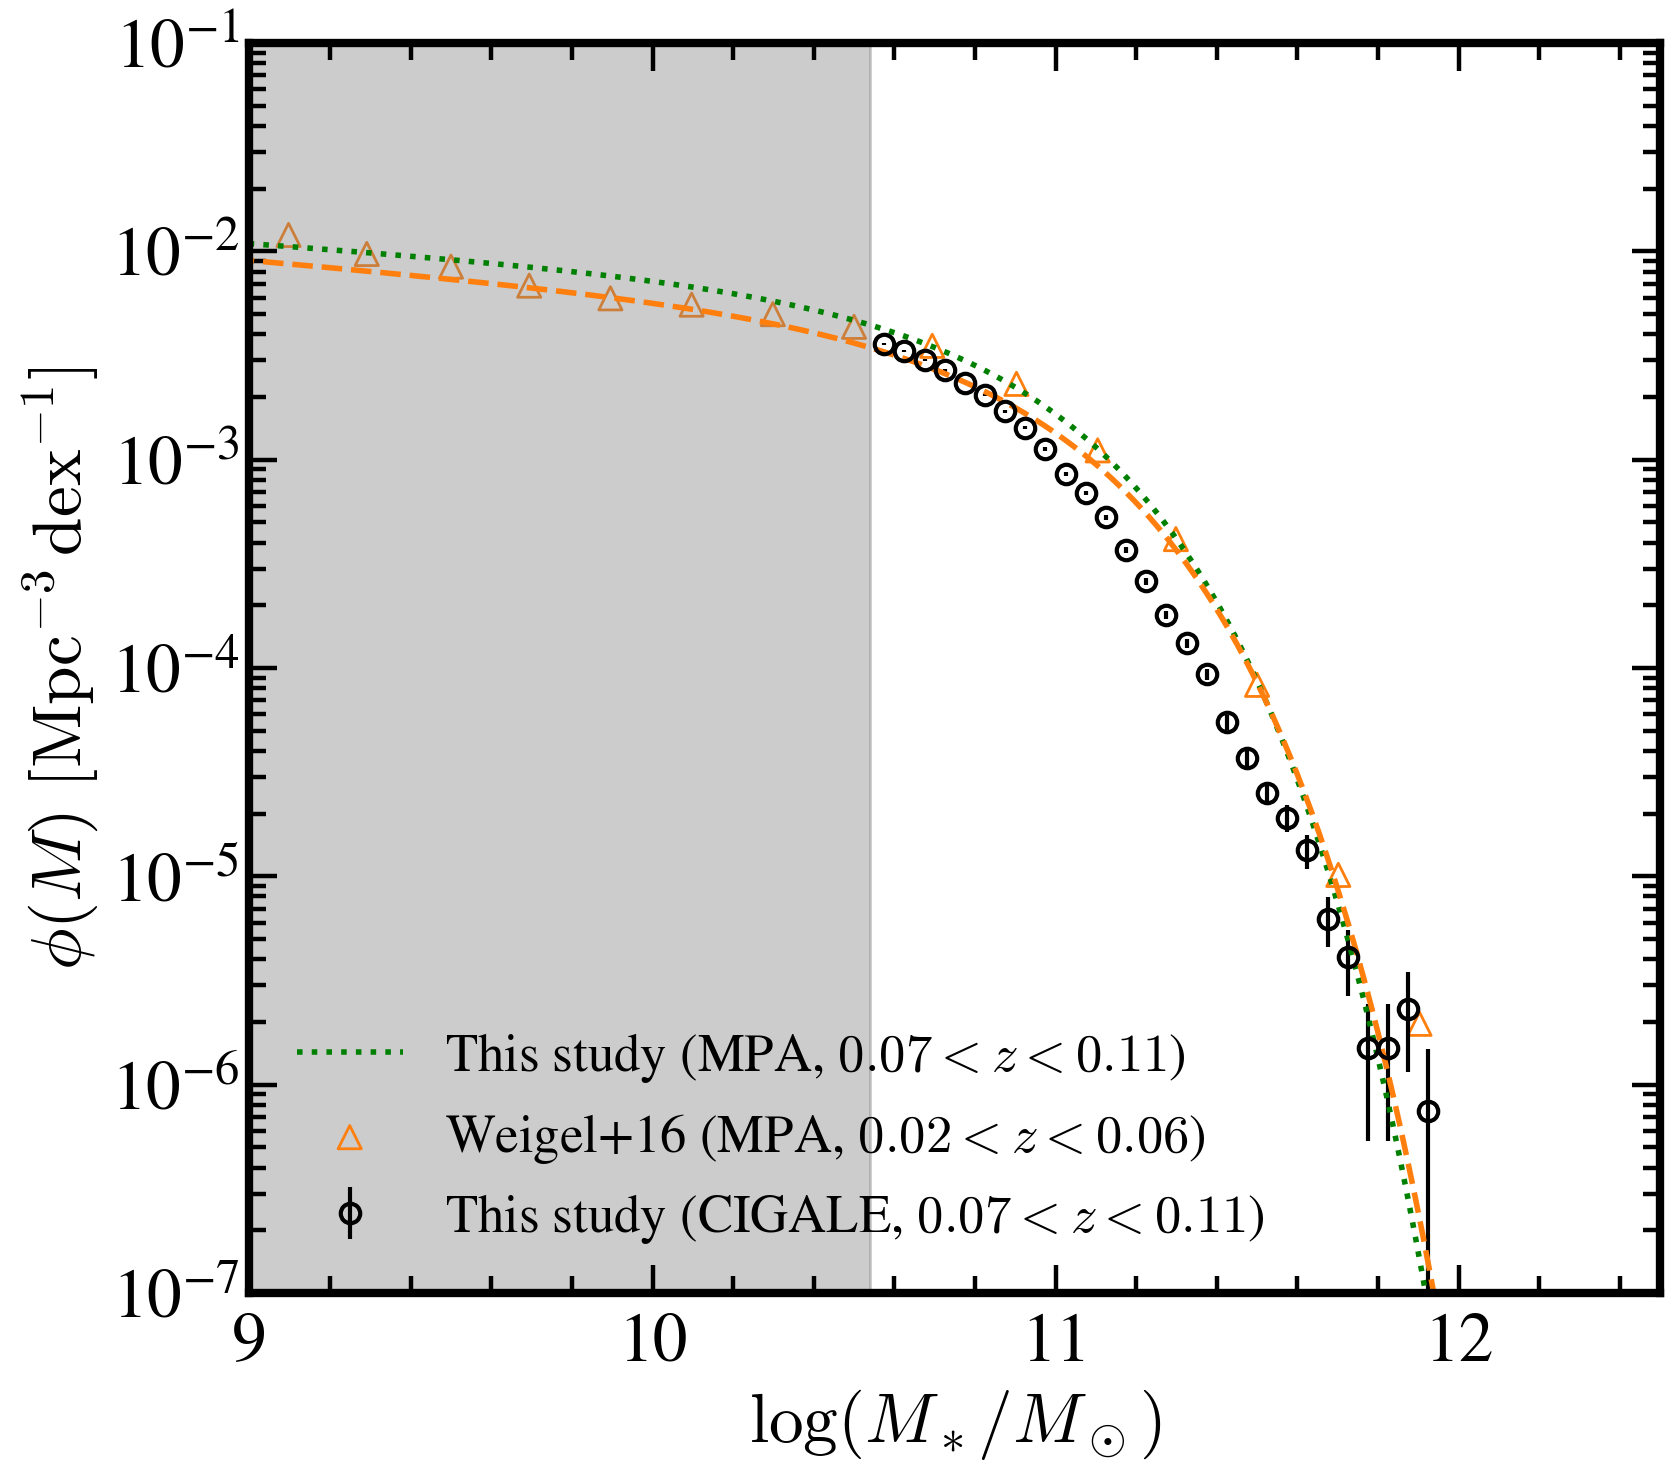

In [11]:
# ============================================================
# Combined SMF panel: CIGALE vs MPA-induced vs Weigel+16 (Figure 13)
# ============================================================
# Uses the results of the two blocks above:
# - CIGALE block: mass_cens, phi_arr, err_up_arr, err_lo_arr, M_COMPLETE_LIM, M_model, curve_wgl
# - MPA-induced block: FIELD_SMF_MLIM_INDUCED, M_plot, phi_schechter, M_fit

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_yscale("log")
ax.set_xlim(9.0, 12.5)
ax.set_ylim(1e-7, 1e-1)

# -----------------------------
# 1) This study: CIGALE SMF (points + simple symmetric errors)
# -----------------------------
cig_mask   = (~np.isnan(phi_arr)) & (mass_cens >= M_COMPLETE_LIM)
M_cig      = mass_cens[cig_mask]
phi_cig    = phi_arr[cig_mask]
phi_cig_err = 0.5 * (err_up_arr[cig_mask] + err_lo_arr[cig_mask])

ax.errorbar(
    M_cig, phi_cig,
    yerr=phi_cig_err,
    fmt="o", mfc="none", mec="black",
    ms=7, mew=1.5,
    ecolor="black", elinewidth=1.5,
    capsize=0,
    label=r"This study (CIGALE, $0.07<z<0.11$)",
)

# -----------------------------
# 2) This study: MPA-induced SMF (Schechter fit only)
# -----------------------------
ax.plot(
    M_plot,
    phi_schechter,
    linestyle=":",
    color="green",
    lw=2,
    label=r"This study (MPA, $0.07<z<0.11$)",
)

# -----------------------------
# 3) Weigel+16 (MPA, SDSS) – literature curve + data points
#     (orange dashed line + orange triangles)
# -----------------------------
ax.plot(
    M_model,
    curve_wgl,
    linestyle="--",
    color="C1",
    lw=2,
)
ax.scatter(
    ok_wgl["Mass"],
    ok_wgl["phi"],
    marker="^",
    facecolors="none",
    edgecolors="C1",
    s=70,
    label=r"Weigel+16 (MPA, $0.02<z<0.06$)",
)

# -----------------------------
# 4) Completeness shading and cosmetics
# -----------------------------
shade_lim = min(M_COMPLETE_LIM, FIELD_SMF_MLIM_INDUCED)
ax.axvspan(7.0, shade_lim, color="gray", alpha=0.4)

ax.set_xlabel(r"$\log(M_*/M_\odot)$")
ax.set_ylabel(r"$\phi(M)\ [\mathrm{Mpc}^{-3}\,\mathrm{dex}^{-1}]$")

ax.minorticks_on()
ax.tick_params(which="both", direction="in", top=True, right=True)
for spine in ax.spines.values():
    spine.set_linewidth(3)

ax.legend(fontsize=19, loc="lower left", frameon=False)

plt.tight_layout()
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure13.pdf", format="pdf", dpi=150, bbox_inches="tight")
plt.show()